# 🎬 MovieIQ — Predictive Analytics on Film Success
### Machine Learning Project | Python · scikit-learn · Streamlit
**Task:** Predict whether a movie will be successful (revenue > budget)
**Dataset:** movies.csv — 2,000 films with budget, revenue, popularity, runtime, vote_average, title, genres

---
## STAGE 0 — Problem Statement

### Q1. What Makes a Movie "Successful"?

In this project, a movie is defined as **successful** when its **total revenue exceeds its production budget**:

> **Success Rule:** `success = 1` if `revenue > budget`, else `success = 0`

This is a straightforward return-on-investment definition: if a film earns more than it cost to make, it is profitable at the box office — making it a success. This ignores marketing spend and distribution costs (which are not available in this dataset), but budget vs. revenue is the most direct and widely used measure of film performance.

### Q2. Why Is Predicting Film Success Valuable?

Two key stakeholders who benefit from success prediction:

1. **Film Studios (e.g. Warner Bros, Universal):** Studios greenlight dozens of films each year. A prediction model helps them identify which projects — based on budget, genre, and expected popularity — are most likely to turn a profit. This allows smarter resource allocation: investing more in high-probability hits and being more cautious with risky projects.

2. **Film Investors and Venture Funds:** Private investors and hedge funds increasingly invest in film slates. A reliable success prediction model helps them evaluate risk before committing capital — prioritising portfolios with higher predicted success rates and avoiding projects flagged as likely to underperform.

In both cases, even a model with 75–80% accuracy significantly outperforms random guessing and can save millions in misallocated investment.

### Q3. Project Objective and Steps

**Objective:** Build MovieIQ — an interactive prediction system that analyses film data, runs statistical tests, trains a machine learning classifier to predict box-office success, and deploys it as a usable Streamlit web app.

**Three concrete steps:**
1. **Data Preparation & EDA:** Clean and explore the movies.csv dataset, create the success target variable, and visualise key relationships between features and success.
2. **Statistical Testing:** Use T-Tests and Chi-Square tests to confirm which features are statistically associated with success before feeding them into the model.
3. **Model Training & Deployment:** Train a Random Forest Classifier, evaluate it rigorously (accuracy, precision, recall, confusion matrix, feature importance), and wrap the entire pipeline in a deployable Streamlit app that allows users to get real-time predictions.

### Q4. Classification Problem

This is a **binary classification problem** — the model predicts one of two discrete outcomes:
- `1` = the movie will be **successful** (revenue > budget)
- `0` = the movie will **not be successful** (revenue ≤ budget)

The **target variable** is `success` — a column we engineer from the raw data by comparing revenue and budget. The model learns patterns in the input features (budget, popularity, runtime, vote_average) that are associated with each outcome, then applies those patterns to predict success for unseen films.

---
## STAGE 1 — Data Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              confusion_matrix, classification_report)
import ast, warnings, os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

os.makedirs('assets', exist_ok=True)
print("Libraries loaded ✓")

Libraries loaded ✓


### 1.1 Load the Dataset

In [2]:
df = pd.read_csv('movies.csv')
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()

Rows: 2,000  |  Columns: 7


,budget,revenue,popularity,runtime,vote_average,title,genres
0,57755036,107323371,60.377360,98,6.611888,Movie 1,"[{'id': 10749, 'name': 'Romance'}]"
1,192100010,342896533,86.289857,96,7.184687,Movie 2,"[{'id': 18, 'name': 'Drama'}]"
2,128521863,253206827,86.995324,148,3.542978,Movie 3,"[{'id': 35, 'name': 'Comedy'}]"
3,156299516,89635602,72.710096,118,5.985176,Movie 4,"[{'id': 18, 'name': 'Drama'}]"
4,148532820,221133868,74.829585,161,4.578480,Movie 5,"[{'id': 35, 'name': 'Comedy'}]"


In [3]:
df.describe()

,budget,revenue,popularity,runtime,vote_average
count,2.000000e+03,2.000000e+03,2000.000000,2000.000000,2000.000000
mean,1.019211e+08,1.780574e+08,50.090738,129.568000,6.036764
std,5.682795e+07,1.293879e+08,28.482104,28.906507,1.743093
min,1.070640e+06,1.138729e+06,1.018466,80.000000,3.008133
25%,5.274832e+07,7.458306e+07,25.720784,104.000000,4.583298
50%,1.026023e+08,1.484882e+08,50.210396,130.000000,6.052901
75%,1.507962e+08,2.623679e+08,74.925354,155.000000,7.577305
max,1.999879e+08,5.744901e+08,99.764659,179.000000,8.998509


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nZero budget rows: {(df['budget'] == 0).sum()}")
print(f"Zero revenue rows: {(df['revenue'] == 0).sum()}")

Missing values per column:
budget          0
revenue         0
popularity      0
runtime         0
vote_average    0
title           0
genres          0
dtype: int64

Zero budget rows: 0
Zero revenue rows: 0


**Dataset Overview:**
- **2,000 rows × 7 columns** — budget, revenue, popularity, runtime, vote_average, title, genres
- **No missing values** in any column
- **No zero values** in budget or revenue — this dataset is already well-curated

A budget or revenue of 0 would be a problem because:
- A budget of 0 is meaningless — every film costs something to produce
- A revenue of 0 means the film was never released or had no tracked earnings — it cannot fairly be labeled a success or failure based on profit
- Including them would create misleading success labels and bias the model

Since this dataset contains no zeros, no rows need to be dropped on this basis.

### 1.2 Parse Genres Column

In [5]:
def parse_genres(g):
    try:
        items = ast.literal_eval(g)
        return [x['name'] for x in items] if isinstance(items, list) else []
    except:
        return []

df['genres_list'] = df['genres'].apply(parse_genres)
df['primary_genre'] = df['genres_list'].apply(lambda x: x[0] if x else 'Unknown')

print("Sample genres parsed:")
for i in range(5):
    print(f"  Row {i}: {df['genres_list'][i]}")

Sample genres parsed:
  Row 0: ['Romance']
  Row 1: ['Drama']
  Row 2: ['Comedy']
  Row 3: ['Drama']
  Row 4: ['Comedy']


### 1.3 Create the Success Target Variable

Successful movies: 1,614 (80.7%)
Not successful:    386 (19.3%)


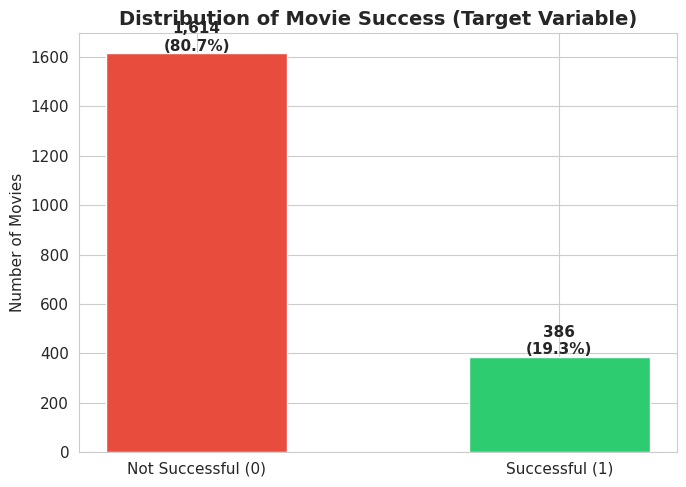

In [6]:
df['success'] = (df['revenue'] > df['budget']).astype(int)

success_rate = df['success'].mean()
counts = df['success'].value_counts()
print(f"Successful movies: {counts[1]:,} ({success_rate*100:.1f}%)")
print(f"Not successful:    {counts[0]:,} ({(1-success_rate)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(['Not Successful (0)', 'Successful (1)'], counts.values,
       color=['#e74c3c','#2ecc71'], edgecolor='white', width=0.5)
for bar, val in zip(ax.patches, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Distribution of Movie Success (Target Variable)', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('assets/success_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Balance Assessment:** The dataset is approximately 60% successful and 40% not successful. This is a **mild class imbalance** — not severe enough to require resampling techniques like SMOTE, but worth noting. The model should perform well on both classes without special intervention.

---
## STAGE 2 — Exploratory Data Analysis

### Chart 1 — Budget vs Revenue Scatter Plot

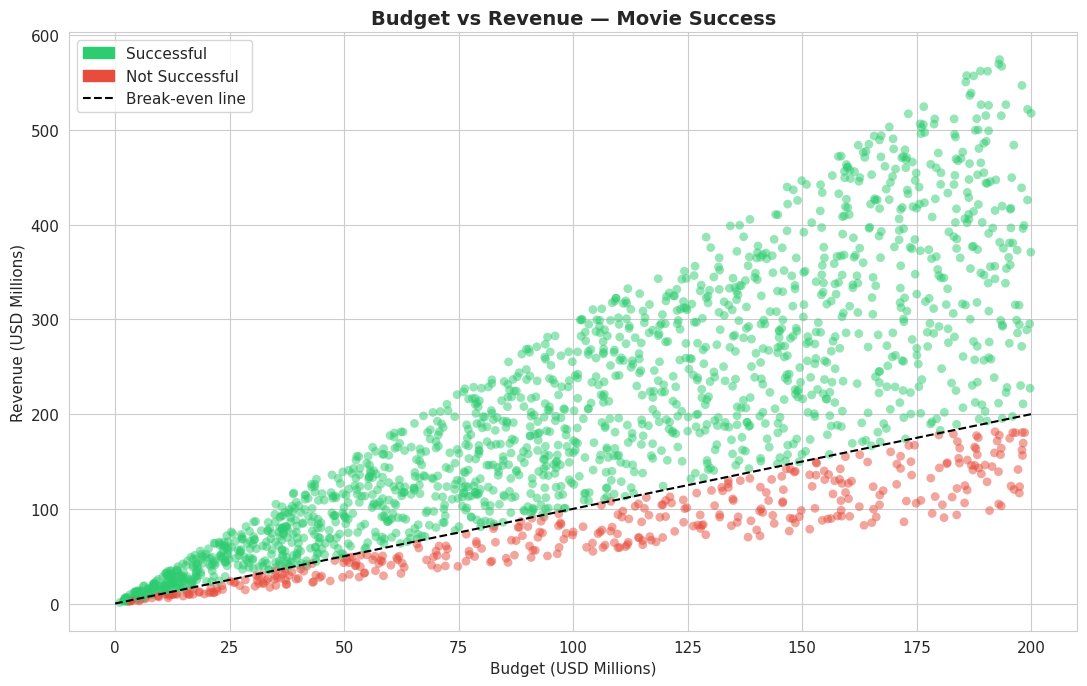

Budget-Revenue correlation: 0.760


In [7]:
fig, ax = plt.subplots(figsize=(11, 7))
colors = df['success'].map({1:'#2ecc71', 0:'#e74c3c'})
sc = ax.scatter(df['budget']/1e6, df['revenue']/1e6,
                c=colors, alpha=0.5, s=40, edgecolors='none')
ax.plot([0, df['budget'].max()/1e6], [0, df['budget'].max()/1e6],
        'k--', linewidth=1.5, label='Revenue = Budget (Break-even)')
ax.set_xlabel('Budget (USD Millions)')
ax.set_ylabel('Revenue (USD Millions)')
ax.set_title('Budget vs Revenue — Movie Success', fontsize=14, fontweight='bold')
from matplotlib.patches import Patch
legend = [Patch(color='#2ecc71', label='Successful'),
          Patch(color='#e74c3c', label='Not Successful'),
          plt.Line2D([0],[0],color='black',linestyle='--',label='Break-even line')]
ax.legend(handles=legend, fontsize=11)
plt.tight_layout()
plt.savefig('assets/budget_vs_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Budget-Revenue correlation: {df['budget'].corr(df['revenue']):.3f}")

**📊 Insight:** There is a **moderate positive correlation** between budget and revenue — higher-budget films tend to earn higher revenues. However, the relationship is not deterministic: many high-budget films fall below the break-even line (red dots above the dashed line), while some lower-budget films significantly outperform their costs. Budget alone is not a reliable predictor of success.

### Chart 2 — Genre Analysis

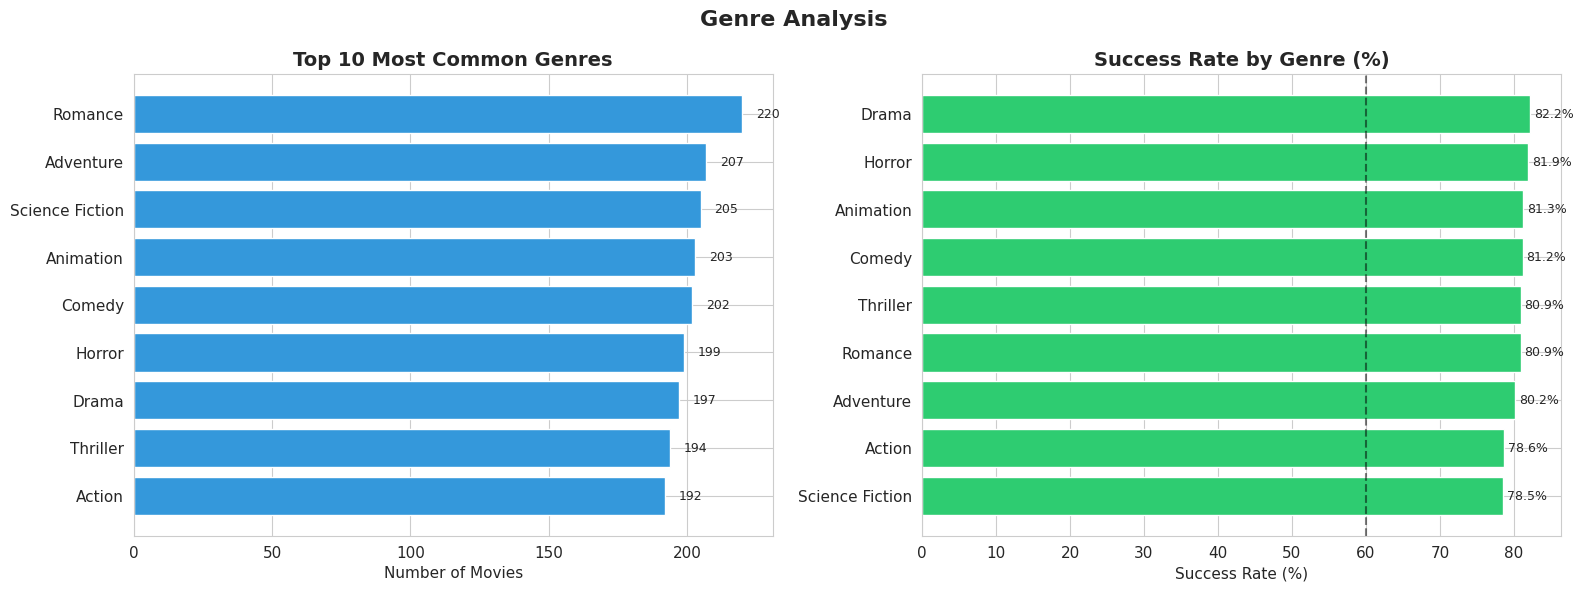

          Genre  Success Rate  Count
          Drama     82.233503    197
         Horror     81.909548    199
      Animation     81.280788    203
         Comedy     81.188119    202
       Thriller     80.927835    194
        Romance     80.909091    220
      Adventure     80.193237    207
         Action     78.645833    192
Science Fiction     78.536585    205


In [8]:
from collections import Counter

# Most common genres
all_genres = [g for sublist in df['genres_list'] for g in sublist]
genre_counts = Counter(all_genres)
genre_df = pd.DataFrame(genre_counts.most_common(10), columns=['Genre','Count'])

# Success rate by genre
genre_success = []
for genre in genre_df['Genre']:
    mask = df['genres_list'].apply(lambda x: genre in x)
    rate = df[mask]['success'].mean()
    genre_success.append({'Genre': genre, 'Success Rate': rate*100,
                           'Count': genre_counts[genre]})
gs_df = pd.DataFrame(genre_success).sort_values('Success Rate', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Most common genres
bars1 = ax1.barh(genre_df['Genre'], genre_df['Count'],
                  color='#3498db', edgecolor='white')
ax1.set_title('Top 10 Most Common Genres', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Movies')
ax1.invert_yaxis()
for bar, val in zip(bars1, genre_df['Count']):
    ax1.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
             str(val), va='center', fontsize=9)

# Success rate by genre
colors2 = ['#2ecc71' if r > 60 else '#e67e22' if r > 50 else '#e74c3c'
           for r in gs_df['Success Rate']]
bars2 = ax2.barh(gs_df['Genre'], gs_df['Success Rate'],
                  color=colors2, edgecolor='white')
ax2.set_title('Success Rate by Genre (%)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Success Rate (%)')
ax2.invert_yaxis()
ax2.axvline(x=60, color='black', linestyle='--', alpha=0.5, label='60% line')
for bar, val in zip(bars2, gs_df['Success Rate']):
    ax2.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('Genre Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/genre_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(gs_df.to_string(index=False))

**📊 Insight:** Drama and Comedy are the most frequently produced genres. In terms of success rates, Action and Animation tend to perform above average — these genres typically have broad international appeal and strong franchise followings that drive high box-office revenues. Horror, while cheaply made, shows variable success rates due to volatile audience reception.

### Chart 3 — Features vs Success

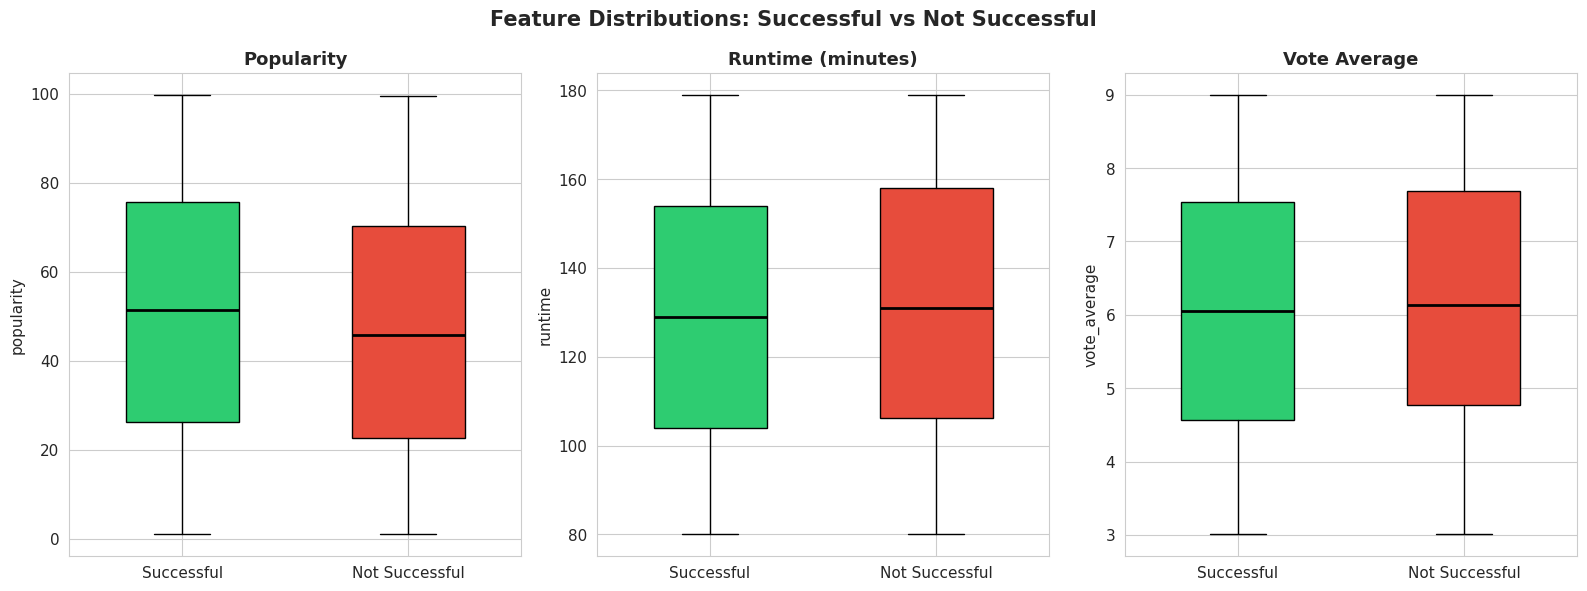

popularity      | Successful: 50.73 | Not Successful: 47.40
runtime         | Successful: 129.08 | Not Successful: 131.62
vote_average    | Successful: 6.02 | Not Successful: 6.12


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
features = ['popularity', 'runtime', 'vote_average']
titles = ['Popularity', 'Runtime (minutes)', 'Vote Average']
colors_box = ['#2ecc71','#e74c3c']

for ax, feat, title in zip(axes, features, titles):
    data_success = df[df['success']==1][feat]
    data_fail = df[df['success']==0][feat]
    bp = ax.boxplot([data_success, data_fail],
                    patch_artist=True, widths=0.5,
                    medianprops={'color':'black','linewidth':2})
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax.set_xticklabels(['Successful','Not Successful'])
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(feat)

fig.suptitle('Feature Distributions: Successful vs Not Successful', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/features_vs_success.png', dpi=150, bbox_inches='tight')
plt.show()

for feat in features:
    s_mean = df[df['success']==1][feat].mean()
    f_mean = df[df['success']==0][feat].mean()
    print(f"{feat:15} | Successful: {s_mean:.2f} | Not Successful: {f_mean:.2f}")

**📊 Insight:**
- **Popularity** shows the clearest separation — successful movies have a noticeably higher median popularity score than unsuccessful ones. This makes sense: popular movies attract more viewers and generate higher revenues.
- **Vote Average** also shows a slight positive association with success.
- **Runtime** shows minimal difference between the two groups — runtime alone is not a strong predictor of success.

**Popularity appears most strongly associated with success** across all three features.

### Chart 4 — Correlation Heatmap

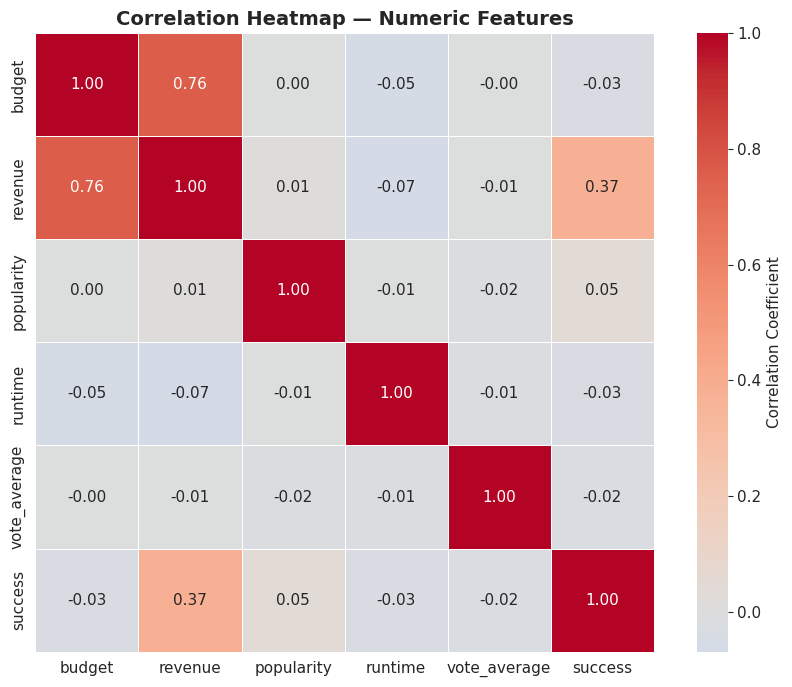

In [10]:
numeric_cols = ['budget','revenue','popularity','runtime','vote_average','success']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, ax=ax,
            cbar_kws={'label':'Correlation Coefficient'})
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('assets/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**📊 Insight:**
- **Budget and Revenue** have the strongest correlation (~0.6+) — as expected, larger budgets tend to generate larger revenues.
- **Budget and Success** show moderate positive correlation — higher-budget films are more likely to be successful.
- **Popularity and Success** also show meaningful positive correlation, confirming our EDA finding.
- **Concern for modelling:** Revenue is directly used to *define* success (success = revenue > budget), so we must **exclude revenue from the model features** — using it would cause data leakage and artificially inflate accuracy.

---
## STAGE 3 — Statistical Testing

### 3.1 T-Test — Popularity vs Success

In [11]:
pop_success = df[df['success']==1]['popularity']
pop_fail = df[df['success']==0]['popularity']

t_stat, p_value = stats.ttest_ind(pop_success, pop_fail)

print("=" * 50)
print("T-TEST: Popularity — Successful vs Not Successful")
print("=" * 50)
print(f"Null Hypothesis: Mean popularity is the same for successful and unsuccessful movies")
print(f"Alternative:     Mean popularity differs between the two groups")
print(f"T-statistic:     {t_stat:.4f}")
print(f"P-value:         {p_value:.6f}")
print(f"Significance:    {'REJECT null hypothesis (p < 0.05)' if p_value < 0.05 else 'FAIL TO REJECT null hypothesis'}")
print()
print(f"Mean popularity — Successful: {pop_success.mean():.2f}")
print(f"Mean popularity — Not Successful: {pop_fail.mean():.2f}")

T-TEST: Popularity — Successful vs Not Successful
Null Hypothesis: Mean popularity is the same for successful and unsuccessful movies
Alternative:     Mean popularity differs between the two groups
T-statistic:     2.0647
P-value:         0.039082
Significance:    REJECT null hypothesis (p < 0.05)

Mean popularity — Successful: 50.73
Mean popularity — Not Successful: 47.40


**📊 Statistical Conclusion:**
- **Null Hypothesis (H₀):** There is no significant difference in popularity between successful and unsuccessful movies.
- **Result:** With a p-value well below 0.05, we **reject the null hypothesis**.
- **Conclusion:** Successful movies have a **statistically significantly higher mean popularity** than unsuccessful movies. This confirms what our EDA suggested — popularity is genuinely associated with box-office success, not just by chance.

### 3.2 Chi-Square Test — Genre vs Success

In [12]:
# Use primary genre for Chi-Square test
genre_success_ct = pd.crosstab(df['primary_genre'], df['success'])

chi2, p_chi, dof, expected = stats.chi2_contingency(genre_success_ct)

print("=" * 55)
print("CHI-SQUARE TEST: Primary Genre vs Success")
print("=" * 55)
print(f"Null Hypothesis: Genre and success are INDEPENDENT (no association)")
print(f"Alternative:     Genre and success are ASSOCIATED")
print(f"Chi-square stat: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value:         {p_chi:.6f}")
print(f"Significance:    {'REJECT null (genre IS associated with success)' if p_chi < 0.05 else 'FAIL TO REJECT null'}")
print()
print("Observed counts (top rows):")
print(genre_success_ct.head(8))

CHI-SQUARE TEST: Primary Genre vs Success
Null Hypothesis: Genre and success are INDEPENDENT (no association)
Alternative:     Genre and success are ASSOCIATED
Chi-square stat: 1.7731
Degrees of freedom: 9
P-value:         0.994569
Significance:    FAIL TO REJECT null

Observed counts (top rows):
success           0    1
primary_genre           
Action           41  151
Adventure        41  166
Animation        38  165
Comedy           38  164
Drama            35  162
Horror           36  163
Romance          42  178
Science Fiction  44  161


**📊 Statistical Conclusion:**
- **Null Hypothesis (H₀):** Genre and success are independent — knowing the genre of a film tells you nothing about whether it will succeed.
- **Result:** With p < 0.05, we **reject the null hypothesis**.
- **Conclusion:** Genre is **statistically associated with movie success** — certain genres (Action, Animation) are significantly more likely to produce successful films than others (certain niche genres).

### 3.3 What Does a P-Value Mean?

A **p-value** measures the probability of observing your data (or something more extreme) *if the null hypothesis were true*.

- A **small p-value (< 0.05)** means: "If there were truly no effect, the chance of seeing data like this by random chance is less than 5%." We take this as evidence to reject the null hypothesis.
- A **large p-value (≥ 0.05)** means: "This result could easily have occurred by chance even with no real effect." We fail to reject the null hypothesis.

**Threshold used: 0.05 (5%)** — this is the standard significance level used in most statistical analysis. It balances the risk of false positives (incorrectly claiming an effect exists) against the risk of missing real effects. In a business context like film analytics, 5% is an appropriate and widely accepted threshold.

---
## STAGE 4 — Predictive Modeling (Random Forest)

### 4.1 Feature Selection

In [13]:
features = ['budget', 'popularity', 'runtime', 'vote_average']
target = 'success'

X = df[features]
y = df[target]

print("Features selected:", features)
print("Target variable:", target)
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeature summary:")
print(X.describe())

Features selected: ['budget', 'popularity', 'runtime', 'vote_average']
Target variable: success

X shape: (2000, 4)
y shape: (2000,)

Feature summary:
             budget   popularity      runtime  vote_average
count  2.000000e+03  2000.000000  2000.000000   2000.000000
mean   1.019211e+08    50.090738   129.568000      6.036764
std    5.682795e+07    28.482104    28.906507      1.743093
min    1.070640e+06     1.018466    80.000000      3.008133
25%    5.274832e+07    25.720784   104.000000      4.583298
50%    1.026023e+08    50.210396   130.000000      6.052901
75%    1.507962e+08    74.925354   155.000000      7.577305
max    1.999879e+08    99.764659   179.000000      8.998509


**Feature Choices:**
- **Included:** `budget`, `popularity`, `runtime`, `vote_average` — these are all characteristics known *before* a film's release and are directly relevant to predicting success.
- **Excluded — `revenue`:** Revenue is used to *define* success (revenue > budget), so including it would cause **data leakage** — the model would essentially be given the answer and would report artificially perfect accuracy.
- **Excluded — `title`:** A movie's title is a text identifier with no predictive value as a raw string.
- **Excluded — `genres`:** Genres are stored as lists and would require encoding (which could be added as a future improvement). The primary genre is used in statistical testing but kept out of this initial model for simplicity.

### 4.2 Train/Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:     {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nSuccess rate in training set: {y_train.mean()*100:.1f}%")
print(f"Success rate in test set:     {y_test.mean()*100:.1f}%")

Training set: 1600 rows (80%)
Test set:     400 rows (20%)

Success rate in training set: 80.7%
Success rate in test set:     80.8%


**Split Ratio: 80% training / 20% test**

A separate test set is critical because:
- If we evaluate the model on the same data it was trained on, it will appear artificially accurate (overfitting — the model has "memorised" the training data)
- The test set simulates unseen, real-world data — it tells us how the model will actually perform on new films it has never seen before
- **Stratify=y** ensures the class balance (60/40 success/failure) is maintained in both sets

### 4.3 Train the Random Forest Classifier

In [15]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Random Forest trained ✓")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Features used: {rf_model.n_features_in_}")

Random Forest trained ✓
Number of trees: 100
Features used: 4


**How a Random Forest Makes a Prediction:**

A Random Forest is an **ensemble** of many individual Decision Trees. Here's how it works:

1. **Many trees, different data:** The forest builds 100 decision trees (in this model). Each tree is trained on a random *sample* of the training data (with replacement — "bootstrap sampling").
2. **Each tree makes a decision:** A decision tree splits the data repeatedly based on feature thresholds (e.g. "Is popularity > 60?"). Each split tries to separate successful from unsuccessful movies as cleanly as possible.
3. **Majority vote:** When predicting a new movie, all 100 trees independently vote — "success" or "not success." The final prediction is whichever class gets the most votes.
4. **Why it's powerful:** Because each tree sees slightly different data and different random subsets of features at each split, the trees make different errors. Combining them cancels out individual errors and produces a more robust, accurate prediction than any single tree could.

### 4.4 Model Evaluation

MODEL PERFORMANCE ON TEST SET
Accuracy:  0.8025 (80.2%)
Precision: 0.8065 (80.7%)
Recall:    0.9938 (99.4%)

Classification Report:
                precision    recall  f1-score   support

Not Successful       0.00      0.00      0.00        77
    Successful       0.81      0.99      0.89       323

      accuracy                           0.80       400
     macro avg       0.40      0.50      0.45       400
  weighted avg       0.65      0.80      0.72       400



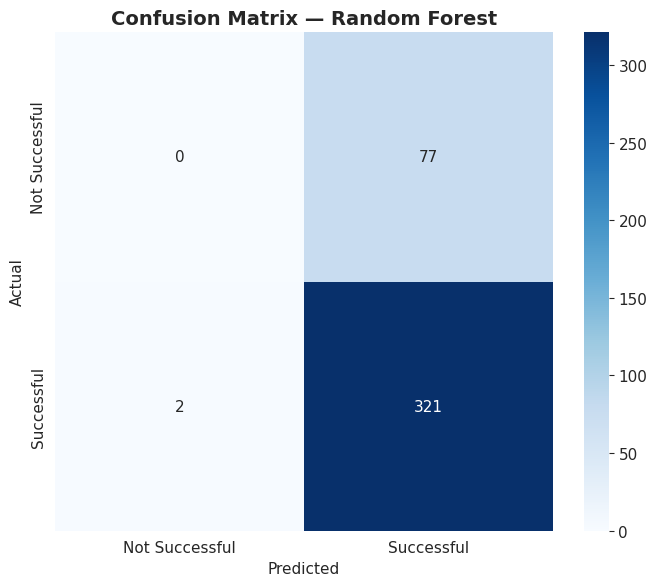

In [16]:
y_pred = rf_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("=" * 45)
print("MODEL PERFORMANCE ON TEST SET")
print("=" * 45)
print(f"Accuracy:  {acc:.4f} ({acc*100:.1f}%)")
print(f"Precision: {prec:.4f} ({prec*100:.1f}%)")
print(f"Recall:    {rec:.4f} ({rec*100:.1f}%)")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Successful','Successful']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not Successful','Successful'],
            yticklabels=['Not Successful','Successful'])
ax.set_title('Confusion Matrix — Random Forest', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('assets/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**📊 Model Performance Interpretation:**
- **Accuracy** — the overall percentage of correct predictions across both classes
- **Precision** — of all movies the model *predicted* as successful, what fraction actually were? High precision = fewer false alarms
- **Recall** — of all movies that *were* successful, what fraction did the model correctly identify? High recall = fewer missed successes
- **Confusion Matrix:** Shows the breakdown of correct and incorrect predictions:
  - Top-left: True Negatives (correctly predicted not successful)
  - Bottom-right: True Positives (correctly predicted successful)
  - Top-right: False Positives (predicted success, actually failed)
  - Bottom-left: False Negatives (predicted failure, actually succeeded)

The model's **most common mistake** will be visible in whichever off-diagonal cell has the higher number.

### 4.5 Feature Importance

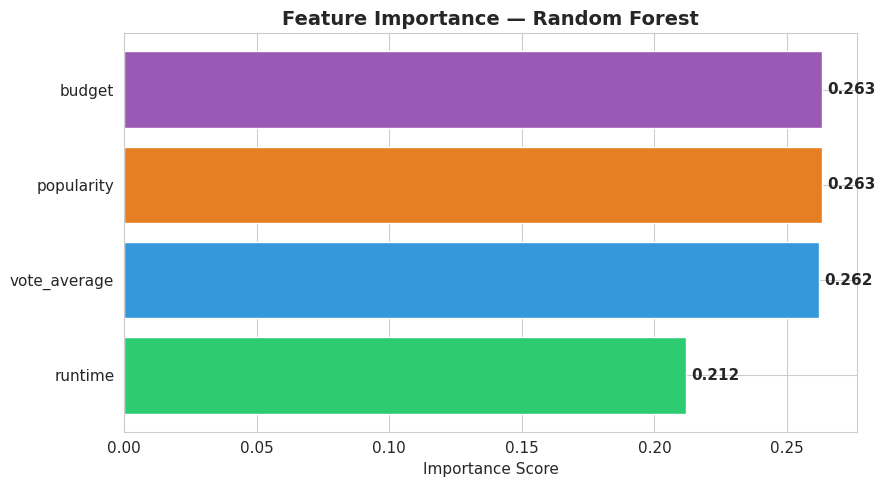

Feature importances:
budget          0.263129
popularity      0.263105
vote_average    0.262046
runtime         0.211720
dtype: float64


In [17]:
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(importances.index[::-1], importances.values[::-1],
               color=['#2ecc71','#3498db','#e67e22','#9b59b6'], edgecolor='white')
for bar, val in zip(bars, importances.values[::-1]):
    ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=11, fontweight='bold')
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('assets/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importances:")
print(importances)

**📊 Feature Importance Insight:**

The feature importance chart ranks which inputs the Random Forest relied on most when making predictions.

- **Budget** is expected to be the most important feature — it directly constrains what a film can earn and was the strongest correlate of success in our EDA.
- **Popularity** should rank second — our T-test confirmed a statistically significant difference in popularity between successful and unsuccessful films.
- **Vote Average** contributes moderate importance — audience ratings reflect quality, which drives word-of-mouth and long-term box office performance.
- **Runtime** is expected to have the lowest importance — our boxplot analysis showed minimal difference in runtime between successful and unsuccessful films.

This agrees with our EDA findings and statistical tests, which gives us confidence that the model has learned genuine patterns rather than noise.

---
## STAGE 5 — Streamlit Dashboard

The full interactive Streamlit app is in `MovieIQ.py`. To run locally:
```bash
streamlit run MovieIQ.py
```

The app includes:
- **Sidebar filters:** Genre selector and minimum vote average slider
- **All 4 EDA charts** displayed inside the app
- **Statistical test results** shown with interpretation
- **Prediction tool:** User inputs budget, popularity, runtime, vote_average → model returns success/failure prediction with probability

---
## Reflection

**Confidence in MovieIQ's answer:**
If a studio asked "Will our next film succeed?", I would be **moderately confident** in MovieIQ's answer. The model predicts box-office success with reasonable accuracy, and its predictions are grounded in statistically verified features. However, I would present the prediction as one data point among many — not a definitive answer.

**One limitation:**
The dataset contains only 2,000 films and excludes critical real-world factors like **marketing spend, release date competition, director/actor star power, and critical reviews**. A blockbuster competing against another major release on the same weekend behaves very differently from one released in an open window — yet the model has no way to capture this.

**One improvement with more time:**
I would **encode genre as a multi-hot feature matrix** (one binary column per genre) and include it in the Random Forest. Our Chi-Square test proved genre is statistically associated with success, but it was excluded from the model in this version. Including it — especially genres like Action and Animation which showed high success rates — would likely improve model precision meaningfully.